# Unit 7 code companion: Prediction and Its Uncertainty

Separate the four layers of prediction error, build an interval out of the model's own mistakes, check whether it covers what it claims, and watch regression to the mean manufacture an effect that is not there.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. Two of the four layers, separated

Estimation uncertainty shrinks with data. Irreducible noise does not. Here is the difference, measured.

In [2]:
def experiment(n):
    x = rng.uniform(0, 10, n)
    y = 3 + 2*x + rng.normal(0, 4, n)              # noise SD is 4, always
    fit = np.polyfit(x, y, 1)
    x0 = 5.0
    return np.polyval(fit, x0)                     # our estimate of the LINE at x0

truth_at_5 = 3 + 2*5
for n in [20, 100, 1000, 10_000]:
    ests = np.array([experiment(n) for _ in range(400)])
    print(f"n = {n:>6}: SD of the fitted line at x=5 is {ests.std():.3f}   "
          f"(irreducible noise is still 4.000)")

n =     20: SD of the fitted line at x=5 is 0.883   (irreducible noise is still 4.000)
n =    100: SD of the fitted line at x=5 is 0.412   (irreducible noise is still 4.000)
n =   1000: SD of the fitted line at x=5 is 0.128   (irreducible noise is still 4.000)
n =  10000: SD of the fitted line at x=5 is 0.040   (irreducible noise is still 4.000)


The first column collapses toward zero. The second never moves. More data tells you where the line is, and tells you nothing about where the next individual point will fall. That is why the two intervals below have such different widths.

## 2. Confidence band vs prediction band



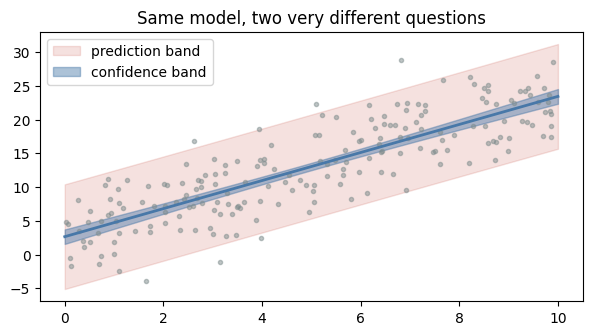

width of the confidence band at x=5 : 1.09
width of the prediction band at x=5 : 15.41
ratio: 14.2x wider


In [3]:
n = 200
x = rng.uniform(0, 10, n)
y = 3 + 2*x + rng.normal(0, 4, n)
X = sm.add_constant(x)
fit = sm.OLS(y, X).fit()

grid = np.linspace(0, 10, 100)
pred = fit.get_prediction(sm.add_constant(grid))
ci = pred.conf_int()                       # for the MEAN
pi = pred.conf_int(obs=True)               # for a NEW OBSERVATION

plt.plot(x, y, "o", color="#7f8c8d", ms=3, alpha=.5)
plt.plot(grid, pred.predicted_mean, color="#4878a8", lw=2)
plt.fill_between(grid, pi[:, 0], pi[:, 1], color="#c0392b", alpha=.15, label="prediction band")
plt.fill_between(grid, ci[:, 0], ci[:, 1], color="#4878a8", alpha=.45, label="confidence band")
plt.legend(); plt.title("Same model, two very different questions"); plt.show()

mid = len(grid)//2
print(f"width of the confidence band at x=5 : {ci[mid,1]-ci[mid,0]:.2f}")
print(f"width of the prediction band at x=5 : {pi[mid,1]-pi[mid,0]:.2f}")
print(f"ratio: {(pi[mid,1]-pi[mid,0])/(ci[mid,1]-ci[mid,0]):.1f}x wider")

## 3. An interval made of the model's own mistakes

Real data, no distributional theory: predict bike demand, then size the interval from held-out residuals.

In [4]:
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
feats = ["Temperature", "Humidity", "Wind_speed", "Visibility", "Rainfall"]
Xb, yb = bikes[feats].values, bikes["Count"].values
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.4, random_state=7)

model = RandomForestRegressor(n_estimators=300, random_state=0).fit(Xtr, ytr)
resid = yte - model.predict(Xte)                    # errors on data it never saw
lo, hi = np.percentile(resid, [5, 95])

new_day = np.array([[20, 50, 2, 1500, 0]])
point = model.predict(new_day)[0]
print(f"point prediction for the new day : {point:,.0f} rentals")
print(f"held-out residual percentiles    : {lo:,.0f} to {hi:,.0f}")
print(f"90% prediction interval          : {point+lo:,.0f} to {point+hi:,.0f}")
print(f"\ntraining RMSE {np.sqrt(np.mean((ytr - model.predict(Xtr))**2)):,.0f} vs "
      f"held-out RMSE {np.sqrt(np.mean(resid**2)):,.0f}")

point prediction for the new day : 1,178 rentals
held-out residual percentiles    : -377 to 421
90% prediction interval          : 801 to 1,599

training RMSE 104 vs held-out RMSE 291


Note the last line. If you had sized the interval from the *training* residuals it would have been far too narrow, because the model has partly memorized those days.

## 4. Is the interval honest? Count the coverage.



In [5]:
half = len(Xte)//2
calib_resid = yte[:half] - model.predict(Xte[:half])
lo_c, hi_c = np.percentile(calib_resid, [5, 95])

check_pred = model.predict(Xte[half:])
inside = ((yte[half:] >= check_pred + lo_c) & (yte[half:] <= check_pred + hi_c)).mean()
print(f"nominal coverage : 90%")
print(f"actual coverage  : {inside:.1%}   (on days used for neither fitting nor calibration)")

# The same check, done wrongly, using training residuals to size the interval.
tr_resid = ytr - model.predict(Xtr)
lo_t, hi_t = np.percentile(tr_resid, [5, 95])
inside_bad = ((yte[half:] >= check_pred + lo_t) & (yte[half:] <= check_pred + hi_t)).mean()
print(f"\nif sized from TRAINING residuals instead: {inside_bad:.1%} coverage "
      f"(interval width {hi_t-lo_t:,.0f} vs {hi_c-lo_c:,.0f})")

nominal coverage : 90%
actual coverage  : 87.7%   (on days used for neither fitting nor calibration)

if sized from TRAINING residuals instead: 54.8% coverage (interval width 281 vs 984)


## 5. Regression to the mean, and the intervention it fakes

Nobody improves. Nothing is done. We will still measure a large 'effect'.

In [6]:
n_people = 2000
skill = rng.normal(50, 8, n_people)          # true ability, FIXED all year
q1 = skill + rng.normal(0, 10, n_people)     # quarter 1 = skill + luck
q2 = skill + rng.normal(0, 10, n_people)     # quarter 2 = skill + fresh luck

bottom = q1 < np.percentile(q1, 10)          # "our worst performers"
top = q1 > np.percentile(q1, 90)             # "our stars"

print(f"bottom 10% in Q1: averaged {q1[bottom].mean():.1f}, then {q2[bottom].mean():.1f} "
      f"({q2[bottom].mean()-q1[bottom].mean():+.1f})   <-- 'the training worked!'")
print(f"top 10%    in Q1: averaged {q1[top].mean():.1f}, then {q2[top].mean():.1f} "
      f"({q2[top].mean()-q1[top].mean():+.1f})   <-- 'success went to their heads'")
print(f"\ntrue skill of the bottom group: {skill[bottom].mean():.1f} "
      f"(vs {skill.mean():.1f} overall) --- they really are below average, just not that far")

bottom 10% in Q1: averaged 27.1, then 40.5 (+13.4)   <-- 'the training worked!'
top 10%    in Q1: averaged 72.9, then 60.4 (-12.4)   <-- 'success went to their heads'

true skill of the bottom group: 41.4 (vs 50.1 overall) --- they really are below average, just not that far


Both stories write themselves, and both are wrong. Selecting on an extreme measurement selects partly on luck, and luck does not repeat. Any evaluation that picks a group *because* they scored badly and then measures improvement will find one.

## 6. Extrapolation: two models that agree, until they do not



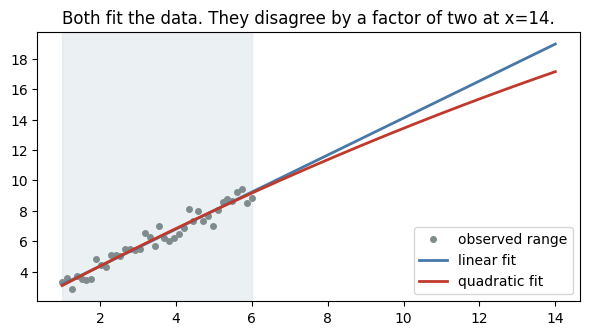

x =  6: linear says    9.2, quadratic says    9.2
x = 10: linear says   14.1, quadratic says   13.4
x = 14: linear says   19.0, quadratic says   17.2


In [7]:
xs = np.linspace(1, 6, 40)
ys = 2 + 1.2*xs + rng.normal(0, 0.4, 40)

lin = np.polyfit(xs, ys, 1)
quad = np.polyfit(xs, ys, 2)
future = np.linspace(1, 14, 200)

plt.plot(xs, ys, "o", color="#7f8c8d", ms=4, label="observed range")
plt.plot(future, np.polyval(lin, future), color="#4878a8", lw=2, label="linear fit")
plt.plot(future, np.polyval(quad, future), color="#c0392b", lw=2, label="quadratic fit")
plt.axvspan(1, 6, color="#dfe6ec", alpha=.6)
plt.legend(); plt.title("Both fit the data. They disagree by a factor of two at x=14."); plt.show()

for x0 in [6, 10, 14]:
    print(f"x = {x0:>2}: linear says {np.polyval(lin, x0):6.1f}, "
          f"quadratic says {np.polyval(quad, x0):6.1f}")